### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [29]:
import pandas as pd
df = pd.read_csv("prostate.data",  sep="\t")
df = df.drop(columns=['Unnamed: 0', 'train'])

print(df)

      lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa
0  -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783
1  -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519
2  -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519
3  -1.203973  3.282789   58 -1.386294    0 -1.386294        6      0 -0.162519
4   0.751416  3.432373   62 -1.386294    0 -1.386294        6      0  0.371564
..       ...       ...  ...       ...  ...       ...      ...    ...       ...
92  2.830268  3.876396   68 -1.386294    1  1.321756        7     60  4.385147
93  3.821004  3.896909   44 -1.386294    1  2.169054        7     40  4.684443
94  2.907447  3.396185   52 -1.386294    1  2.463853        7     10  5.143124
95  2.882564  3.773910   68  1.558145    1  1.558145        7     80  5.477509
96  3.471966  3.974998   68  0.438255    1  2.904165        7     20  5.582932

[97 rows x 9 columns]


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

```
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

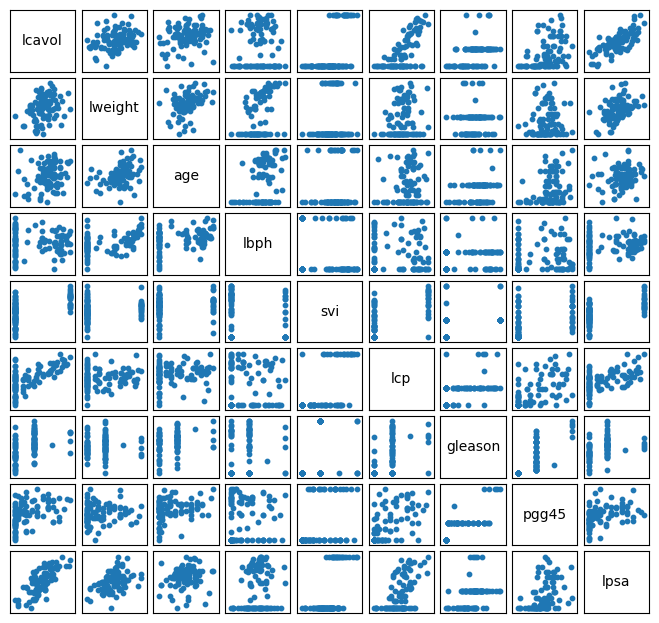

In [30]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)
    return fig, ax

fig, ax = pairplot(df)
plt.show()


**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

Based on the graphic we can see that lpsa seems to be the variable the most correlated to the `lpsa`

In [31]:
print("Data Types:")
print(df.dtypes)
print("\nCorrelation Matrix:")
print(df.corr().loc['lcavol'])

Data Types:
lcavol     float64
lweight    float64
age          int64
lbph       float64
svi          int64
lcp        float64
gleason      int64
pgg45        int64
lpsa       float64
dtype: object

Correlation Matrix:
lcavol     1.000000
lweight    0.280521
age        0.225000
lbph       0.027350
svi        0.538845
lcp        0.675310
gleason    0.432417
pgg45      0.433652
lpsa       0.734460
Name: lcavol, dtype: float64


**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

In [62]:
import numpy as np

def corr(X, Y):
    X = X.astype(float)
    Y = Y.astype(float)
    return np.cov(X, Y)[0, 1] / (np.std(X) * np.std(Y))

print(corr(df['lpsa'], df['lcavol']))




0.7421109546117322


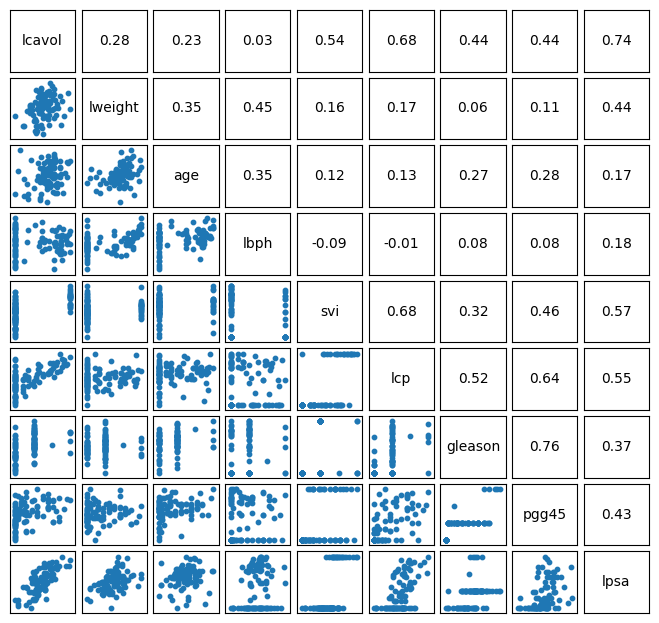

In [63]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot_bis(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i > j:
                axij.scatter(df[i_name], df[j_name], s=10)
            elif i < j:
                X = df[i_name]
                Y = df[j_name]
                axij.text(0.5, 0.5, f"{corr(X, Y):.2f}", fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)
    return fig, ax

fig, ax = pairplot_bis(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters.

In [33]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

Let $\beta_{svi}$ and $\beta_{gleason}$, as well as $X_{svi}$ and $X_{gleason}$ be the dummy variables encoding the qualitative variables svi and gleason. We have 3 gleason variables in the model, and 1 svi.
Let $\beta_0$ be the intercept.

We have : $Y_{lcavol}= \beta_{0} + \beta_{svi1}X_{svi1} + \beta_{gleason7}X_{gleason7}+ \beta_{gleason8}X_{gleason8}+ \beta_{gleason9}X_{gleason9} + \beta_{lweight}X_{lweight} + \beta_{age}X_{age}+  \beta_{lbph}X_{lbph} +  \beta_{lcp}X_{lcp}+  \beta_{pgg45}X_{pgg45}+  \beta_{lpsa}X_{lpsa} +\varepsilon$

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [34]:
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']

- We fix a dtype in pd.get_dummies to be sure that there are no conversion problems during the statistical calculus done afterward with the data
- We drop two columns after the encoding to avoid multicollinearity : the data contained in the columns droped are completely encoded in the other columns. The object must be of the non-represented category if it is not one of the others. It avoids redonduncy, which could interfers with the t-tests.
- We add a column of ones to the dataframe so that the model is not forced to go trough the origin. It serves to predict $\beta_0$, which is the ordonnée à l'origine.

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients.

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`.

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [35]:
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        16:54:06   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Answers:**


*   The regression coeff related to svi and gleason allows us to simulate each of their discrete states regarding the category that has been dropped (here svi_0 and gleason_6)
*   Since svi and gleason are discrete variables, without the one-hot encoding, they would have been treated as continuous variables and the model would have tried to find a linear relation between states.It would have led in problems in the regression and absurd simulations, since it would have created intermediate states that do not exist.
* Overall, by taking a look at the p-value, we see that some variables are more statistically significant than others. For instance, lcp or pgg45 have a very small p-value. On the other hand, variables such as l_weight or the gleason variables have a p-value that is high, which means they might not be very significant to predict lcavol. We can also take a look at the t-test and have the same conclusion: some variables have a high absolute t-value (lcp, lpsa, pgg45) which means that we know they have an effect on the model. On the other hand, lweight has a t-value close to 0 : it may not be useful for the model.




**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [36]:
results.conf_int()

,0,1
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


**Comments**:
We see that some intervals do not contain the value 0. It means that those variables have an impact on lcavol. However, some of the variables contain it, which means that they might have a coefficient of 0, and could have no impact on lcavol. We see that some variables, such as age, have a very small coefficient, but the interval strictly excludes 0. On the other hand, the gleason variables can have a bigger coeff, but they can also have a coeff of 0. Adding those results with the ones of the previous question lead us to think that the gleason variables, lweight and svi may not have a major impact on the lcavol variable.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [37]:
results.pvalues

,0
lweight,9.577075e-01
age,3.014993e-02
lbph,7.695609e-02
lcp,8.577858e-06
pgg45,4.047741e-02
lpsa,2.939241e-08
svi_1,3.922717e-01
gleason_7,1.512950e-01
gleason_8,3.516744e-01
gleason_9,1.087313e-01


**Comments**
We can make assumptions in the same way than the question before: the p-value being almost null, and the confidence interval of the coeff being strictly positive, we can assume that the lpsa variable may be one if not the most important of the variable to estimate lcavol.
The fact that the p-value is almost null means that their is almost no chance that this variable has no effect on lcavol.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [38]:
import numpy as np
from scipy import stats

def calculate_ols_params(X_df, y_series):
    # convert dataframes to numpy arrays for matrix math
    X = X_df.values
    y = y_series.values.reshape(-1, 1)

    # get number of observations (n) and features/parameters (p)
    n = X.shape[0]
    p = X.shape[1]

    # matrix multiplications for XtX and Xty
    XtX = X.T @ X
    Xty = X.T @ y

    # BONUS ANSWER:
    # We use np.linalg.solve instead of np.linalg.inv here to find beta_hat.
    # It is much better because it computes the solution directly using
    # factorization (like LU decomposition). It's faster and far more numerically
    # stable than explicitly calculating the inverse matrix.
    beta_hat = np.linalg.solve(XtX, Xty)

    # get predictions and residuals
    y_pred = X @ beta_hat
    residuals = y - y_pred

    # calculate RSS
    rss = np.sum(residuals**2)

    # calculate residual variance (sigma squared).
    # we have n-p degrees of freedom
    sigma_squared_hat = rss / (n - p)

    # covariance matrix of the coefficients
    # here we use the explicit inverse matrix to get the standard
    # errors, so we use linalg.inv
    XtX_inv = np.linalg.inv(XtX)
    cov_beta = sigma_squared_hat * XtX_inv

    # standard errors with elements of the cov matrix
    se_beta = np.sqrt(np.diag(cov_beta)).reshape(-1, 1)
    t_stats = beta_hat / se_beta
    # calculate two-sided p-values with the t-distribution
    df_residuals = n - p
    p_values = 2 * stats.t.sf(np.abs(t_stats), df_residuals)

    # keep data in a dictionary
    param_names = X_df.columns.tolist()
    results = {}
    for i, name in enumerate(param_names):
        results[name] = {'coef': beta_hat[i, 0],
                        'std err': se_beta[i, 0],
                        't': t_stats[i, 0],
                        'P>|t|': p_values[i, 0]}

    return results, rss

#test
calculated_results, calculated_rss = calculate_ols_params(X, y)


print("{:<15} {:<10} {:<10} {:<10} {:<10}".format("Parameter", "Coef.", "Std.Err.", "t-value", "P>|t|"))
for name, val in calculated_results.items():
    print("{:<15} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        name, val['coef'], val['std err'], val['t'], val['P>|t|']))

print(f"\nRSS: {calculated_rss:}")

Parameter       Coef.      Std.Err.   t-value    P>|t|     
lweight         -0.0112    0.2115     -0.0532    0.9577    
age             0.0248     0.0112     2.2046     0.0301    
lbph            -0.1042    0.0582     -1.7901    0.0770    
lcp             0.4028     0.0851     4.7343     0.0000    
pgg45           -0.0094    0.0045     -2.0803    0.0405    
lpsa            0.5496     0.0901     6.1000     0.0000    
svi_1           -0.2204    0.2564     -0.8598    0.3923    
gleason_7       0.3117     0.2153     1.4478     0.1513    
gleason_8       -0.7106    0.7588     -0.9364    0.3517    
gleason_9       0.7901     0.4875     1.6208     0.1087    
intercept       -1.4067    0.8745     -1.6086    0.1114    

RSS: 41.814068608045346


**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

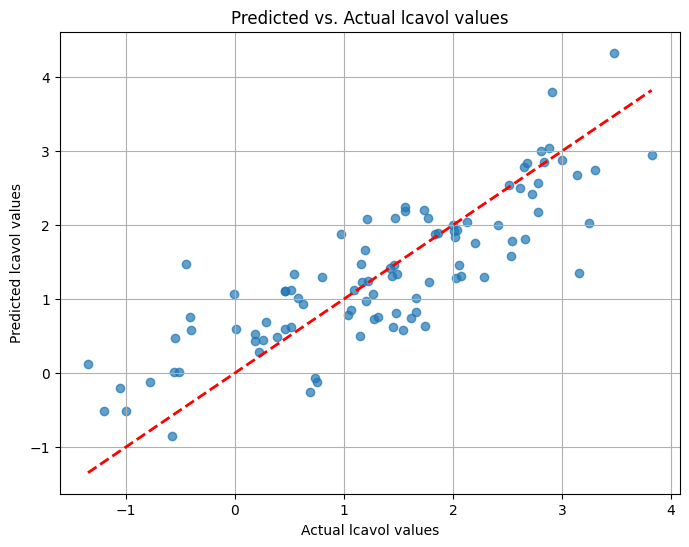

In [39]:
import matplotlib.pyplot as plt


predictions = results.get_prediction(X).predicted_mean

#plot
plt.figure(figsize=(8, 6))
plt.scatter(y, predictions, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) #perfect prediction line
plt.xlabel('Actual lcavol values')
plt.ylabel('Predicted lcavol values')
plt.title('Predicted vs. Actual lcavol values')
plt.grid(True)
plt.show()


**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

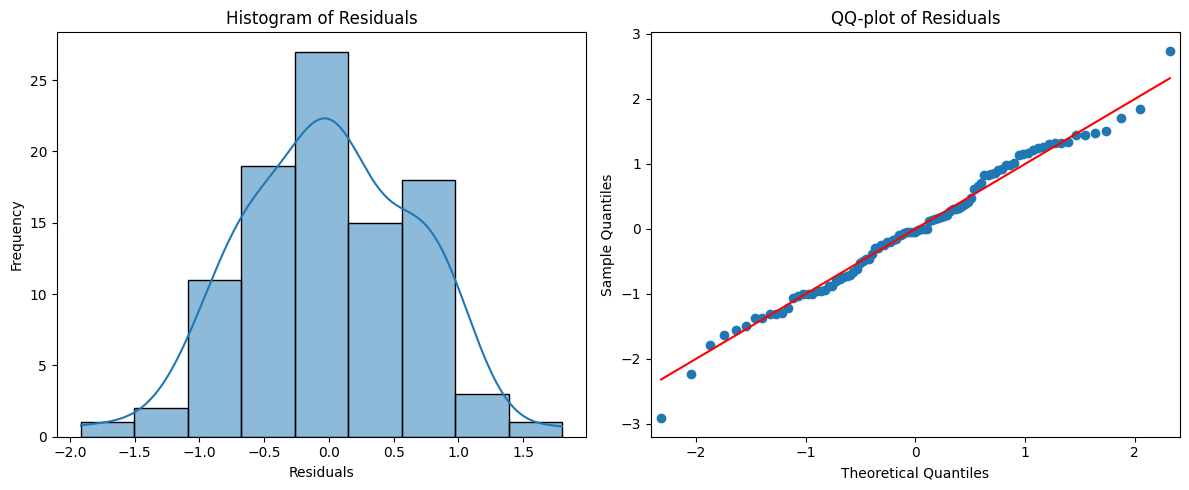

Residual Sum of Squares (RSS): 41.81406860804535


In [40]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import seaborn as sns


residuals = results.resid

#plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='s', fit=True, ax=plt.gca())
plt.title('QQ-plot of Residuals')

plt.tight_layout()
plt.show()

#sum RSS
rss = np.sum(residuals**2)
print(f"Residual Sum of Squares (RSS): {rss}")

**Comments :** The majority of the residuals seems to fall on the straight line y=x. However, the edges deviate, which means that the data has more extreme values than the distribution predicted. We may not admit that the residuals are perfectly normally distributed.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [41]:
import statsmodels.api as sm

# copy to avoid modifying X
X_reduced = df_enc.drop(columns=['lcavol', 'lpsa', 'lcp'])

y = df['lcavol']
model_reduced = sm.OLS(y, X_reduced)
results_reduced = model_reduced.fit()

print("\nOLS Regression Results without lpsa and lcp")
print(results_reduced.summary())



OLS Regression Results without lpsa and lcp
                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        16:54:07   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight

**Comments :** This exercise led us tu understand that lpsa and lcp are the most important parameters in our model. By removing them and making the regression again, the model try to find other parameters to explain the data. We see that the coefficients, t and other values are notably modified. For instance, the lweight variable had a coefficent of about -0.01, which is now 0.5850. However, the standard error is consistent. Moreover, other variables that were previously non-significant are not anymore. For example, the svi_1 variable went from a non-significant coefficient of -0.22 (p-value = 0.392) to a highly significant 1.02 (p-value < 0.001). We observe a similar result for gleason_7.

This phenomenon indicates that our predictors are correlated. When lpsa and lcp are removed, the remaining variables become more informatory to compensate for the loss. However, the overall model quality has significantly degraded. The R-squared dropped drastically from 0.686 to 0.433, meaning our new model explains much less variance in lcavol. Furthermore, the increase in AIC (from 215.7 to 269.2) confirms that removing our two most important parameters resulted in an objectively worse model.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance,

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

In [42]:
# (a):

import itertools
import statsmodels.api as sm

target = 'lcavol'
features = ['svi', 'gleason', 'lweight', 'age', 'lbph', 'lcp', 'pgg45', 'lpsa']

results = []

# for loop for every combination of 2 features:
for combo in itertools.combinations(features, 2):
    # add constant beta0 to X
    X = df[list(combo)]
    X = sm.add_constant(X)
    y = df[target] #lcavol

    # fit model
    model = sm.OLS(y, X).fit()

    # results
    results.append({
        'model': combo,
        'RSS': model.ssr
    })

# find the model that gives the smallest rss
best_model = min(results, key=lambda x: x['RSS'])
print(f"Best Model: {best_model['model']} with RSS: {best_model['RSS']:.4f}")

Best Model: ('lcp', 'lpsa') with RSS: 47.2781


   k         RSS                                           features
0  0  133.359034                                                 ()
1  1   61.420907                                            (lpsa,)
2  2   47.278097                                        (lcp, lpsa)
3  3   46.237825                                   (age, lcp, lpsa)
4  4   44.878406                             (age, lbph, lcp, lpsa)
5  5   44.311332                      (age, lbph, lcp, pgg45, lpsa)
6  6   43.354252             (gleason, age, lbph, lcp, pgg45, lpsa)
7  7   43.179048        (svi, gleason, age, lbph, lcp, pgg45, lpsa)
8  8   43.171699  (svi, gleason, lweight, age, lbph, lcp, pgg45,...


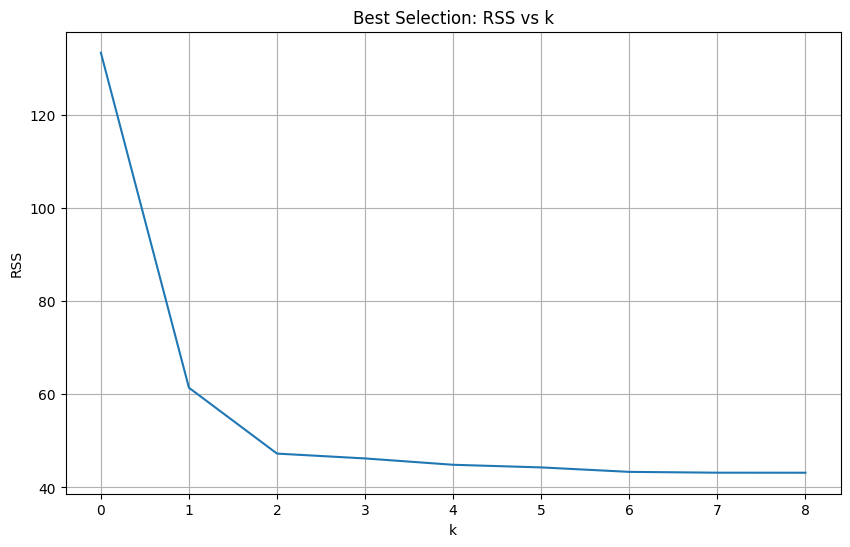

In [43]:
# (b)

best_models = []

for k in range(9):
    best_rss = float('inf')
    best_features = []

    for combo in itertools.combinations(features, k):
        #same drill
        X = df[list(combo)]
        X = sm.add_constant(X)
        y = df[target] #lcavol

        model = sm.OLS(y, X).fit()

        # check for smallest rss
        if model.ssr < best_rss:
            best_rss = model.ssr
            best_features = combo

  # store the model that gives the smallest rss for this k
    best_models.append({
        'k': k,
        'RSS': best_rss,
        'features': best_features
     })
# results
results_df = pd.DataFrame(best_models)
print(results_df)

#  plot
plt.figure(figsize=(10, 6))
plt.plot(results_df['k'], results_df['RSS'])
plt.title('Best Selection: RSS vs k')
plt.xlabel('k')
plt.ylabel('RSS')
plt.grid(True)
plt.xticks(range(9))
plt.show()


(c)

No, minimizing RSS is a poor way to choose the model size for two reasons:
- RSS always goes down by adding new variables even if the extra variables are useless
- Potential overfitting due to always picking the model with the lowest RSS for this current set of data

The training error will naturally drop because the model has more parameters but we don't take into account the complexity of the model by adding more parameters.

Therefore, we should use metrics that punish the model for being too complex.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

Split validation consist to divide our data into two subsets:
- Training set to train the model
- Test set to evaluate our model

If the model is overfitted we will see the problem with the test.

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$.

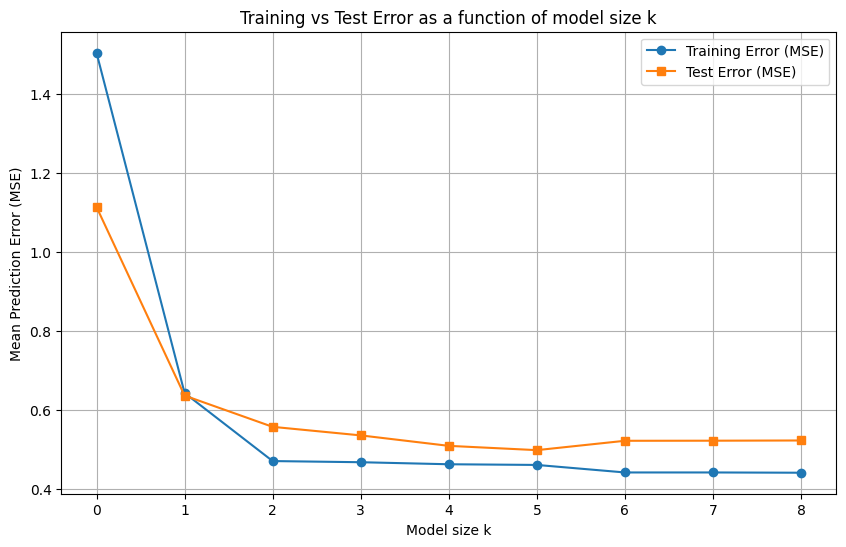

In [44]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import sklearn.model_selection as skl

target = 'lcavol'
features = ['svi', 'gleason', 'lweight', 'age', 'lbph', 'lcp', 'pgg45', 'lpsa']

# Split the full dataset
X_full = df[features]
y_full = df[target]
X_train, X_test, y_train, y_test = skl.train_test_split(X_full, y_full, test_size=0.3, random_state=3)

train_errors = []
test_errors = []

for entry in best_models:
    k = entry['k']
    feats = list(entry['features'])

    if k == 0:
        # Intercept-only model
        X_tr = sm.add_constant(np.ones(len(X_train)), has_constant='add')
        X_te = sm.add_constant(np.ones(len(X_test)), has_constant='add')
    else:
        X_tr = sm.add_constant(X_train[feats])
        X_te = sm.add_constant(X_test[feats])

    # Fit on training set
    model_k = sm.OLS(y_train, X_tr).fit()

    # Mean prediction error on training set
    y_pred_train = model_k.predict(X_tr)
    train_mse = np.mean((y_train.values - y_pred_train) ** 2)

    # Mean prediction error on test set
    y_pred_test = model_k.predict(X_te)
    test_mse = np.mean((y_test.values - y_pred_test) ** 2)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

k_values = [entry['k'] for entry in best_models]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, marker='o', label='Training Error (MSE)')
plt.plot(k_values, test_errors, marker='s', label='Test Error (MSE)')
plt.xlabel('Model size k')
plt.ylabel('Mean Prediction Error (MSE)')
plt.title('Training vs Test Error as a function of model size k')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

The error on our test set is minimal for $k=5$ and then increase for $k>5$ that seems to be the best model four our our dataset

In [45]:
import statsmodels.api as sm
import numpy as np

best_k = 5
best_feats = list(best_models[best_k]['features'])

X_best = sm.add_constant(df[best_feats].astype(float))
y_full = df[target]

final_model = sm.OLS(y_full, X_best).fit()
print(final_model.summary())


                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     36.57
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.25e-20
Time:                        16:54:08   Log-Likelihood:                -99.639
No. Observations:                  97   AIC:                             211.3
Df Residuals:                      91   BIC:                             226.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2995      0.687     -1.893      0.0

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

The main limitation of split-validation is its **high variance**: the estimated test error depends heavily on which samples happen to end up in the train/test split. With a small dataset like this one (97 observations), a single random split can give very different error estimations

**Alternative: K-Fold Cross-Validation.** Instead of a single split, the dataset is divided into $K$ equally-sized folds. The model is trained $K$ times, each time using $K-1$ folds for training and the remaining fold for testing. The final error estimate is the average over all $K$ runs.

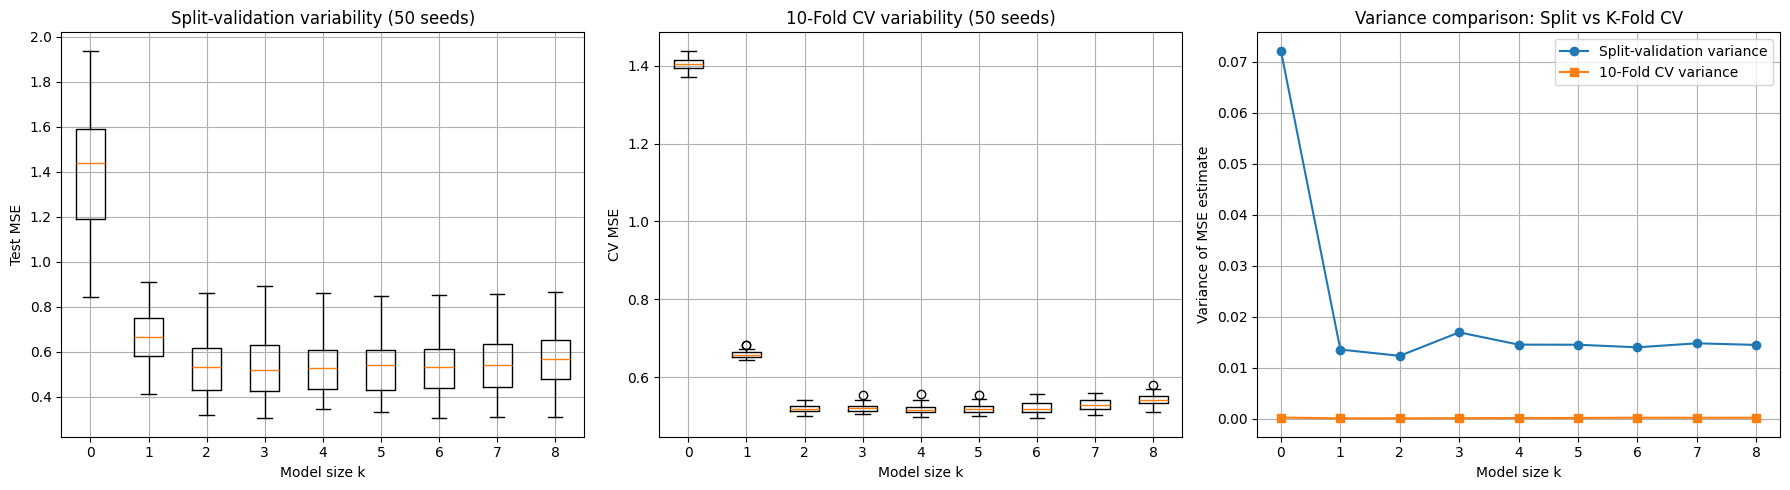

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import KFold, train_test_split

K = 10
n_seeds = 50
k_values = list(range(9))

def build_X(data, feats):
    """Build design matrix with intercept, always same shape regardless of data content."""
    ones = np.ones((len(data), 1))
    if len(feats) == 0:
        return ones
    return np.column_stack([ones, data[feats].astype(float).values])

# --- Illustration of the limitation: variance of a single split across 50 seeds ---
split_test_errors = {k: [] for k in k_values}

for seed in range(n_seeds):
    X_tr, X_te, y_tr, y_te = train_test_split(df[features], df[target], test_size=0.3, random_state=seed)
    for entry in best_models:
        k = entry['k']
        feats = list(entry['features'])
        Xtr = build_X(X_tr, feats)
        Xte = build_X(X_te, feats)
        m = sm.OLS(y_tr.values, Xtr).fit()
        split_test_errors[k].append(np.mean((y_te.values - m.predict(Xte))**2))

# --- K-Fold CV across 50 seeds ---
cv_errors_by_seed = {k: [] for k in k_values}

for seed in range(n_seeds):
    kf = KFold(n_splits=K, shuffle=True, random_state=seed)
    for entry in best_models:
        k = entry['k']
        feats = list(entry['features'])
        fold_errors = []
        for train_idx, test_idx in kf.split(df):
            df_tr, df_te = df.iloc[train_idx], df.iloc[test_idx]
            Xtr = build_X(df_tr, feats)
            Xte = build_X(df_te, feats)
            m = sm.OLS(df_tr[target].values, Xtr).fit()
            fold_errors.append(np.mean((df_te[target].values - m.predict(Xte))**2))
        cv_errors_by_seed[k].append(np.mean(fold_errors))

# --- Variance of each estimator ---
split_vars = [np.var(split_test_errors[k]) for k in k_values]
cv_vars    = [np.var(cv_errors_by_seed[k]) for k in k_values]

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot([split_test_errors[k] for k in k_values], positions=k_values)
axes[0].set_xlabel('Model size k')
axes[0].set_ylabel('Test MSE')
axes[0].set_title('Split-validation variability (50 seeds)')
axes[0].grid(True)

axes[1].boxplot([cv_errors_by_seed[k] for k in k_values], positions=k_values)
axes[1].set_xlabel('Model size k')
axes[1].set_ylabel('CV MSE')
axes[1].set_title(f'{K}-Fold CV variability (50 seeds)')
axes[1].grid(True)

axes[2].plot(k_values, split_vars, marker='o', label='Split-validation variance')
axes[2].plot(k_values, cv_vars,    marker='s', label=f'{K}-Fold CV variance')
axes[2].set_xlabel('Model size k')
axes[2].set_ylabel('Variance of MSE estimate')
axes[2].set_title('Variance comparison: Split vs K-Fold CV')
axes[2].legend()
axes[2].grid(True)
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.show()

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

Best subset selection based on training error led to overfitting by systematically favoring the full 8-predictor model. To achieve the best bias-variance trade-off, split-validation identified an optimal 5-variable model (age, lbph, lcp, pgg45, lpsa). Because split-validation suffers from high variance, 10-Fold Cross-Validation was used to confirm this model size with greater stability, but it also show that we can have almost the quite the same error with $k \in [2,5]$.